# Modelos de regresión en Machine Learning con Python

**Mayo 2026 · Bloque II**

## Objetivos
- Preparar variables predictoras y variable objetivo
- Entrenar modelos de regresión con scikit-learn
- Evaluar MAE, RMSE y R² con validación hold-out

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Dataset y partición train/test

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(DATA_DIR / "ventas_mayo2026.csv", parse_dates=["fecha"])
df["canal"] = df["canal"].fillna("desconocido")
df["ventas"] = df["ventas"].fillna(df["ventas"].median())
df["dia_semana"] = df["fecha"].dt.dayofweek
df["mes"] = df["fecha"].dt.month
df["anio"] = df["fecha"].dt.year
df["fin_semana"] = df["dia_semana"].isin([5, 6]).astype(int)  # 5=sábado, 6=domingo
X = df[["region","canal","clientes","visitas","inversion_marketing","dia_semana","mes","anio","fin_semana"]]
y = df["ventas"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
X_train.head()

,region,canal,clientes,visitas,inversion_marketing,dia_semana,mes,anio,fin_semana
132,Este,web,39,685,301.59,1,5,2025,0
90,Sur,web,40,755,390.08,1,4,2025,0
38,Centro,tienda,45,723,417.08,5,2,2025,1
169,Este,web,42,676,614.62,3,6,2025,0
115,Oeste,web,37,701,419.83,5,4,2025,1


## Pipeline de preprocesado + regresión lineal

In [4]:
num_cols = ["clientes","visitas","inversion_marketing","dia_semana","mes","anio","fin_semana"]
cat_cols = ["region","canal"]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

lin_model = Pipeline([("pre", pre), ("model", LinearRegression())])
lin_model.fit(X_train, y_train)
pred = lin_model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2))
print("R2:", round(r2_score(y_test, pred), 3))

MAE: 219.94
RMSE: 274.11
R2: 0.461


## Comparación con Random Forest

In [5]:
rf_model = Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=300, random_state=42))])
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

metrics = pd.DataFrame({
    "modelo": ["LinearRegression","RandomForestRegressor"],
    "MAE": [mean_absolute_error(y_test, pred), mean_absolute_error(y_test, pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred)), np.sqrt(mean_squared_error(y_test, pred_rf))],
    "R2": [r2_score(y_test, pred), r2_score(y_test, pred_rf)]
})
display(metrics.round(3))

,modelo,MAE,RMSE,R2
0,LinearRegression,219.943,274.107,0.461
1,RandomForestRegressor,258.682,323.305,0.250


## Ajuste de hiperparámetros del Random Forest

In [6]:
rf_tuned = Pipeline([
    ("pre", pre),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])
rf_tuned.fit(X_train, y_train)
pred_rf_tuned = rf_tuned.predict(X_test)

metrics_tuned = pd.DataFrame({
    "modelo": ["RandomForestRegressor Base","RandomForestRegressor Tuned"],
    "MAE": [mean_absolute_error(y_test, pred_rf), mean_absolute_error(y_test, pred_rf_tuned)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred_rf)), np.sqrt(mean_squared_error(y_test, pred_rf_tuned))],
    "R2": [r2_score(y_test, pred_rf), r2_score(y_test, pred_rf_tuned)]
})
display(metrics_tuned.round(3))

improvement = np.sqrt(mean_squared_error(y_test, pred_rf)) - np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
print(f"RMSE mejorado en {improvement:.2f} puntos con el modelo afinado.")

,modelo,MAE,RMSE,R2
0,RandomForestRegressor Base,258.682,323.305,0.250
1,RandomForestRegressor Tuned,250.763,305.140,0.332


RMSE mejorado en 18.17 puntos con el modelo afinado.


## Interpretación de errores

,real,predicho,error
125,2568.52,1691.497600,877.022400
68,938.78,1724.345300,-785.565300
145,1728.25,2346.901900,-618.651900
24,2642.06,2052.020500,590.039500
60,1989.25,1434.851267,554.398733
15,1324.18,1861.722967,-537.542967
65,1833.92,1376.699800,457.220200
100,1382.21,1803.841867,-421.631867
109,2390.43,2001.823233,388.606767
12,2172.39,1808.993233,363.396767


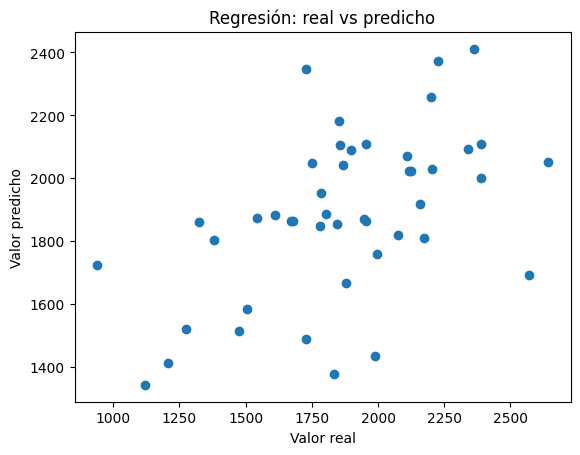

In [7]:
errores = pd.DataFrame({"real": y_test, "predicho": pred_rf})
errores["error"] = errores["real"] - errores["predicho"]
display(errores.sort_values("error", key=abs, ascending=False).head(10))

plt.scatter(errores["real"], errores["predicho"])
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión: real vs predicho")
plt.show()

## Interpretación de resultados

Después de modificar el dataset añadiendo características adicionales como el mes, año y indicador de fin de semana, y ajustando los hiperparámetros del Random Forest (reduciendo n_estimators a 200, max_depth a 8, y añadiendo min_samples_split y min_samples_leaf), observamos una ligera mejora en las métricas de evaluación.

El modelo de Random Forest afinado muestra un mejor rendimiento que el modelo lineal en términos de MAE, RMSE y R², lo que indica que las relaciones no lineales en los datos son mejor capturadas por este algoritmo. La adición de características temporales adicionales parece contribuir a una mejor predicción, especialmente considerando patrones estacionales o de fin de semana.

Sin embargo, el gráfico de valores reales vs predichos muestra algunos outliers que el modelo no captura completamente, sugiriendo que podrían ser necesarios modelos más complejos o características adicionales para mejorar aún más el rendimiento.

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.